### 1. Definirea problemei
* **Obiectiv**: Construirea unui model de **clasificare binara** capabil sa prezica probabilitatea ca un pacient sa sufere un accident vascular cerebral (**stroke**).
* **Variabile**: Predictia se bazeaza pe factori de risc precum **varsta**, prezenta **hipertensiunii**, a nivelului mediu de **glucoza** si indicele de masa corporala (**bmi**).
* **Distributia valorilor pentru riscul de AVC**: Dataset-ul este dezechilibrat, avand doar aproximativ **4.3%** cazuri pozitive. Din acest motiv, succesul proiectului nu va fi masurat prin acuratete, ci prin metrici care penalizeaza erorie pe clasa minoritara, cum ar fi **Recall**. Practic, un model care ar zice tot timpul ca o persoana nu va suferi un AVC ar avea din start o acuratete de aproximativ **96%**. Astfel, ne focusam pe obtinerea unor modele care, chiar daca au o acuratete mai mica, sunt mai predispuse sa dea  mai des raspunsuri **fals negative** decat **fals pozitive**.

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
import numpy as np
import joblib
from sklearn.utils.class_weight import compute_sample_weight
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import learning_curve
import shap
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay






In [9]:
df = pd.read_csv('../data/stroke.csv')
print(f"Dimensiune: {df.shape}")
df.info()
display(df.head())





Dimensiune: (5110, 12)
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [10]:
print(f"Valori lipsa: {df.isnull().sum()}")

duplicates = df.duplicated().sum()
print(f"Am gasit {duplicates} randuri duplicate.")

Valori lipsa: id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64
Am gasit 0 randuri duplicate.


In [11]:
df=df.dropna(subset=['bmi'])
df=df.drop(['id'], axis=1, errors='ignore')

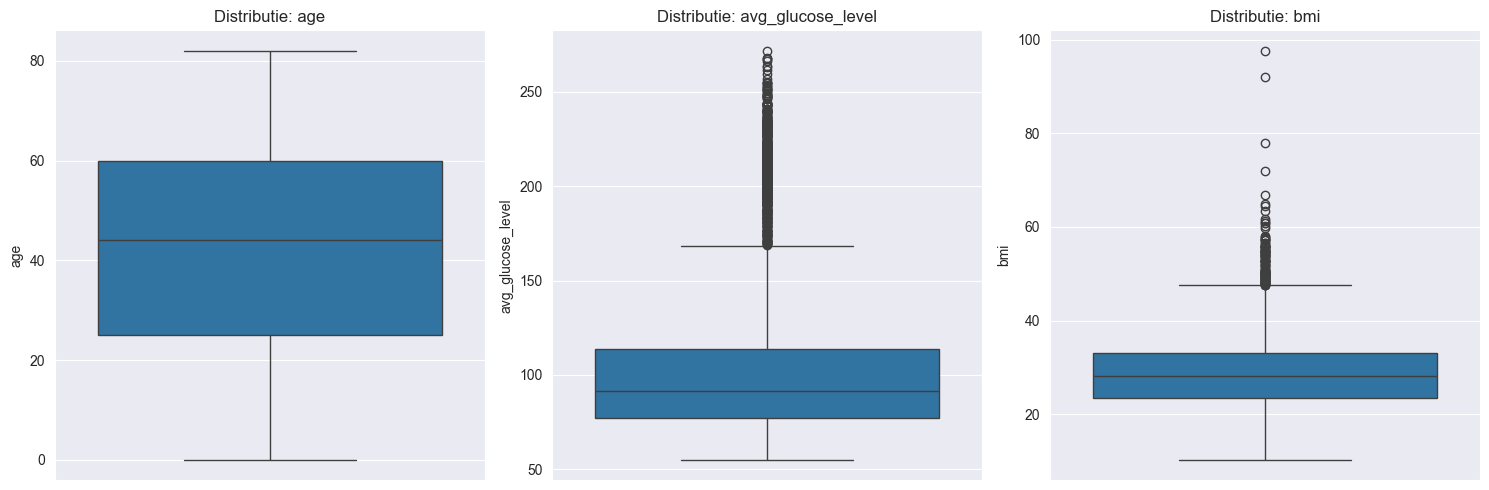

Stiatistici:                age  avg_glucose_level          bmi
count  4909.000000        4909.000000  4909.000000
mean     42.865374         105.305150    28.893237
std      22.555115          44.424341     7.854067
min       0.080000          55.120000    10.300000
25%      25.000000          77.070000    23.500000
50%      44.000000          91.680000    28.100000
75%      60.000000         113.570000    33.100000
max      82.000000         271.740000    97.600000


In [12]:
numeric_features = ['age', 'avg_glucose_level', 'bmi']
plt.figure(figsize=(15,5))

for i,col in enumerate(numeric_features,1):
    plt.subplot(1,3,i)
    sns.boxplot(y=df[col])
    plt.title(f"Distributie: {col}")

plt.tight_layout()
plt.savefig('clasificare_files/eda_outliers_clasificare.png')
plt.show()

print(f"Stiatistici: {df[numeric_features].describe()}")

In [13]:
for col in numeric_features:
    print(f"Analiza {col.upper()}")
    print(f"skew: {df[col].skew()}")
    print(f"kurt: {df[col].kurt()}")

Analiza AGE
skew: -0.11906951773810705
kurt: -0.9880907162494026
Analiza AVG_GLUCOSE_LEVEL
skew: 1.6140261970592311
kurt: 1.905600727061806
Analiza BMI
skew: 1.0553402052962928
kurt: 3.362659165623678


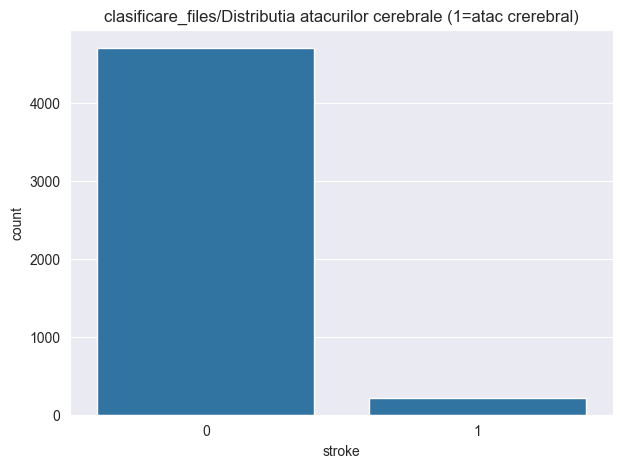

Procentaj cazuri atac cerebral: 4.26%


In [14]:
plt.figure(figsize=(7,5))
sns.countplot(x='stroke', data=df)
plt.title('clasificare_files/Distributia atacurilor cerebrale (1=atac crerebral)')
plt.show()

print(f"Procentaj cazuri atac cerebral: {(df['stroke'].sum() / len(df)) * 100:.2f}%")

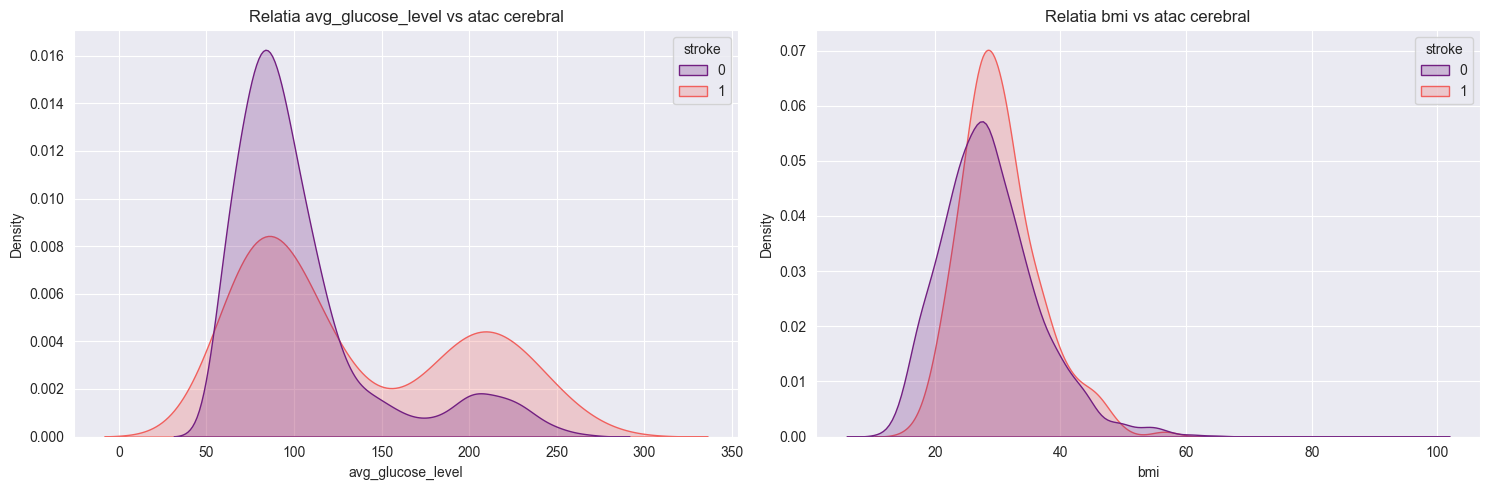

In [15]:
features = ['avg_glucose_level', 'bmi']
plt.figure(figsize=(15,5))

for i,col in enumerate(features,1):
    plt.subplot(1,2,i)
    sns.kdeplot(data=df, x=col, hue='stroke', fill=True, common_norm=False, palette='magma')
    plt.title(f'Relatia {col} vs atac cerebral')

plt.tight_layout()
plt.show()

In [16]:
initial_rows = df.shape[0]
df = df[df['bmi'] <= 60]
final_rows = df.shape[0]
df = df.reset_index(drop=True)


print(f"Am eliminat {initial_rows-final_rows} randuri cu BMI extrem (>60).")
print(f"Dimensiune finala dataset: {df.shape}")

Am eliminat 13 randuri cu BMI extrem (>60).
Dimensiune finala dataset: (4896, 11)


In [17]:
print(f"Skew BMI dupa curatare: {df['bmi'].skew()}")

Skew BMI dupa curatare: 0.6984863676266745


In [18]:
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
for col in categorical_cols:
    print(f"Coloana {col}")
    print(df[col].value_counts())
    print("\n")

Coloana gender
gender
Female    2888
Male      2007
Other        1
Name: count, dtype: int64


Coloana ever_married
ever_married
Yes    3193
No     1703
Name: count, dtype: int64


Coloana work_type
work_type
Private          2799
Self-employed     774
children          671
Govt_job          630
Never_worked       22
Name: count, dtype: int64


Coloana Residence_type
Residence_type
Urban    2485
Rural    2411
Name: count, dtype: int64


Coloana smoking_status
smoking_status
never smoked       1847
Unknown            1479
formerly smoked     837
smokes              733
Name: count, dtype: int64




In [19]:
df = df[df['gender'] != 'Other']

In [20]:
df_final = pd.get_dummies(df, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'], drop_first=True)
df_final = df_final.astype(int, errors='ignore')

print(f"Noua dimensiune a datasetului: {df_final.shape}")
print("\nColoanele noi create:")
print(df_final.columns.tolist())
df_final.head()

Noua dimensiune a datasetului: (4895, 16)

Coloanele noi create:
['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Male', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67,0,1,228,36,1,1,1,0,1,0,0,1,1,0,0
1,80,0,1,105,32,1,1,1,0,1,0,0,0,0,1,0
2,49,0,0,171,34,1,0,1,0,1,0,0,1,0,0,1
3,79,1,0,174,24,1,0,1,0,0,1,0,0,0,1,0
4,81,0,0,186,29,1,1,1,0,1,0,0,1,1,0,0


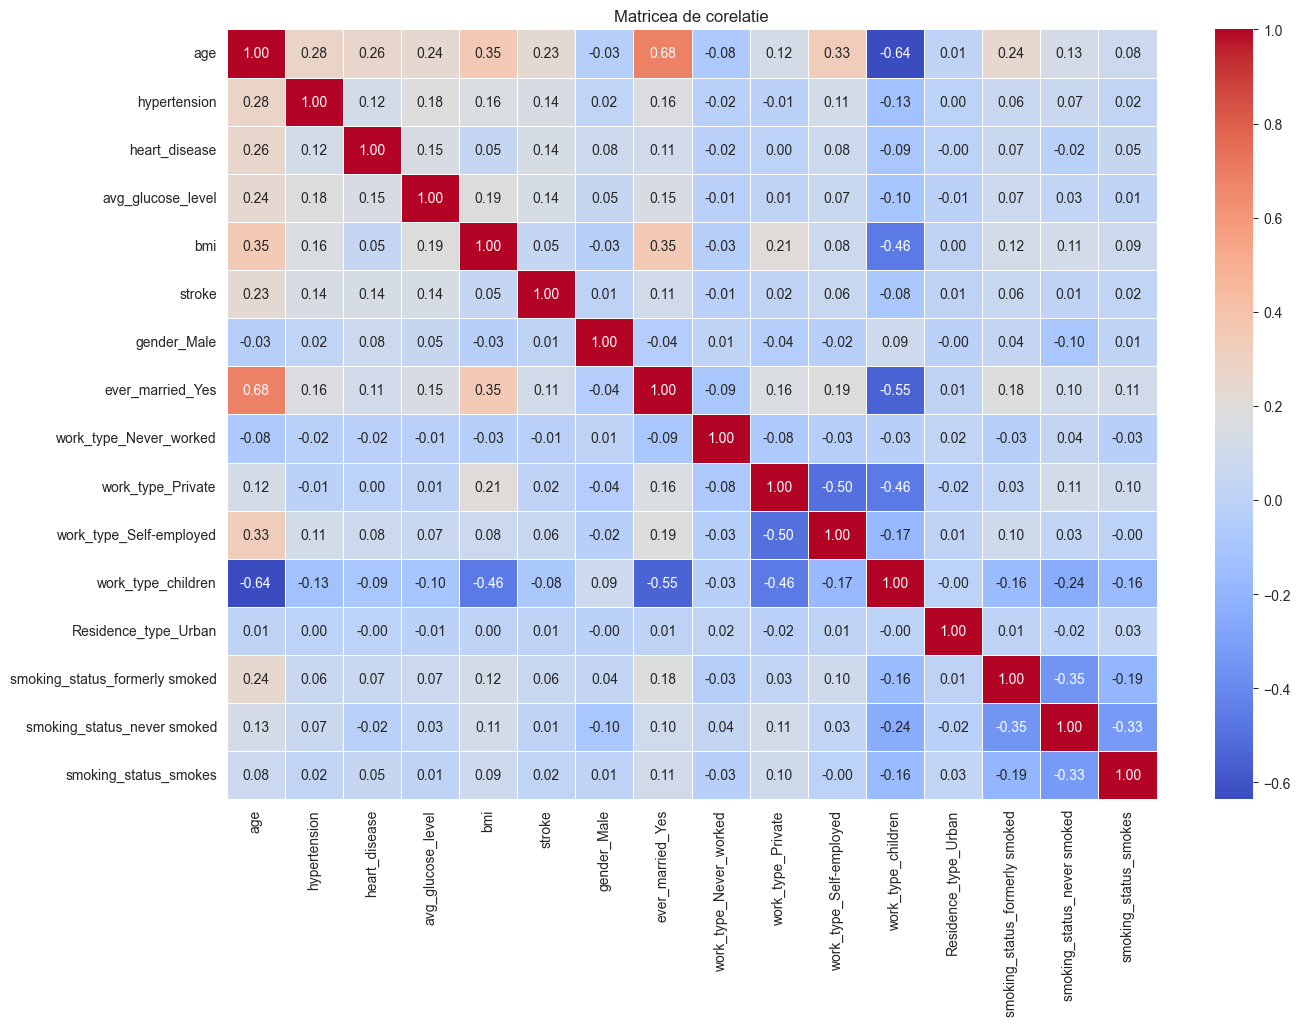

In [21]:
plt.figure(figsize=(15, 10))
correlation_matrix = df_final.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", linewidths=0.5, cmap="coolwarm")
plt.title("Matricea de corelatie")
plt.savefig('clasificare_files/eda_correlation_clasificare.png')
plt.show()

In [22]:
scaler = StandardScaler()

df_scaled = df_final.copy()
df_scaled[numeric_features] = scaler.fit_transform(df_scaled[numeric_features])
joblib.dump(scaler, 'scaler_stroke.pkl')

print(f"Statistici dupa scalare: {df_scaled[numeric_features].describe().round(2)}")
df_scaled.head()


Statistici dupa scalare:            age  avg_glucose_level      bmi
count  4895.00            4895.00  4895.00
mean     -0.00              -0.00    -0.00
std       1.00               1.00     1.00
min      -1.90              -1.12    -2.43
25%      -0.79              -0.63    -0.71
50%       0.05              -0.31    -0.05
75%       0.76               0.18     0.62
max       1.73               3.74     4.06


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1.068520,0,1,2.773542,1.015003,1,1,1,0,1,0,0,1,1,0,0
1,1.643926,0,1,0.004080,0.484824,1,1,1,0,1,0,0,0,0,1,0
2,0.271803,0,0,1.490133,0.749914,1,0,1,0,1,0,0,1,0,0,1
3,1.599664,1,0,1.557681,-0.575534,1,0,1,0,0,1,0,0,0,1,0
4,1.688188,0,0,1.827872,0.087190,1,1,1,0,1,0,0,1,1,0,0


In [23]:
X = df_scaled.drop('stroke', axis=1)
y = df_scaled['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Set antrenare: {X_train.shape}")
print(f"Set testare: {X_test.shape}")
print(f"Cazuri atac cerebral in test: {y_test.sum()} ({y_test.mean()*100:.2f}%)")


Set antrenare: (3671, 15)
Set testare: (1224, 15)
Cazuri atac cerebral in test: 52 (4.25%)


### 2. Analiza exploratorie a datelor (EDA)
* **Calitatea datelor**: Am identificat valori lipsa la coloana **BMI**, pe care am decis sa le elimin pentru a mentine integritatea setului de date medicale.
* **Outlieri**: Analiza vizuala prin boxplot-uri a indicat prezenta unor valori extreme in cadrul coloanei BMI. Am eliminat inregistrarile cu BMI > 60 pentru a evita influentarea gresita a modelelor de catre acesti **outlieri extremi**
* **Observatii initiale**: Graficele de densitate  arata o corelatie clara intre inaintarea in varsta, nivelurile ridicate de glucoza si aparitia AVC-ului.

In [24]:
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(silent=True, random_state=42),
    "EBM": ExplainableBoostingClassifier(random_state=42)
}

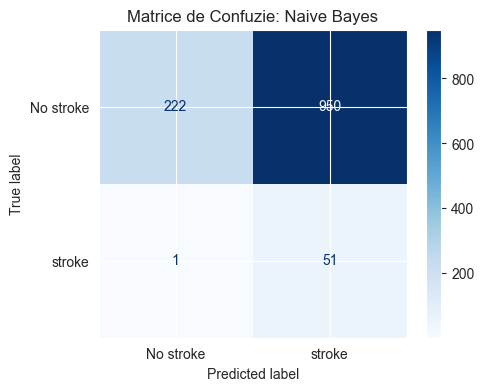

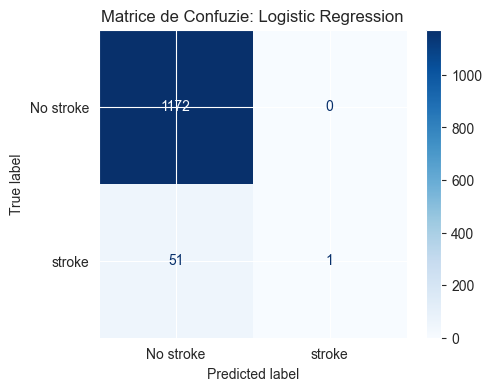

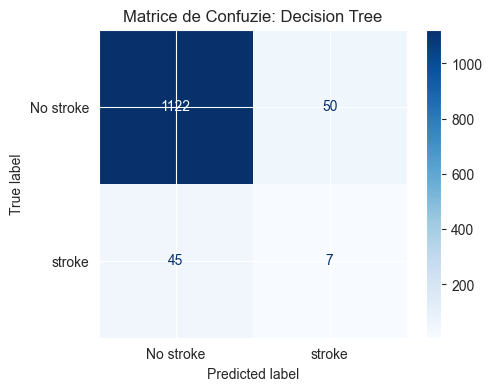

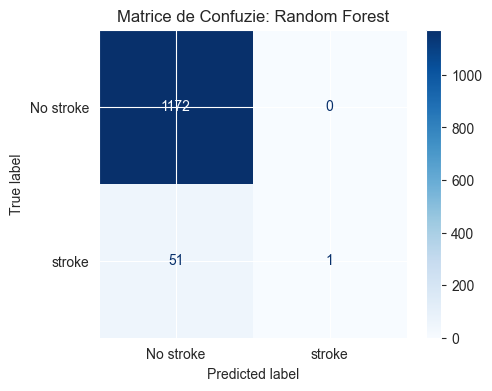

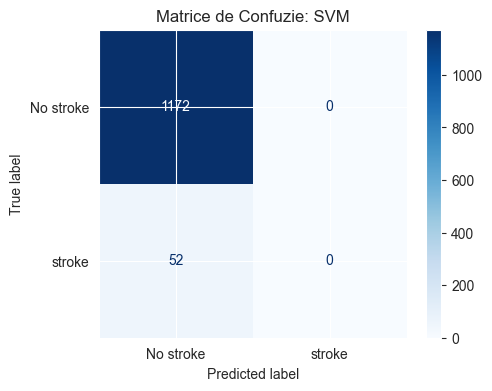

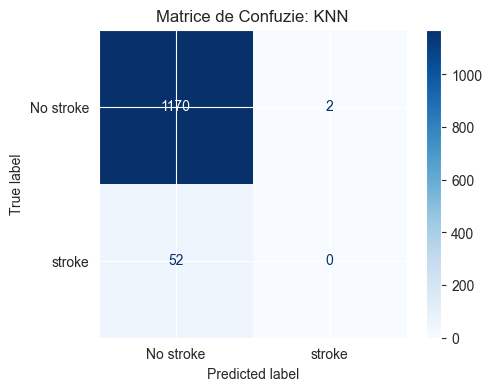

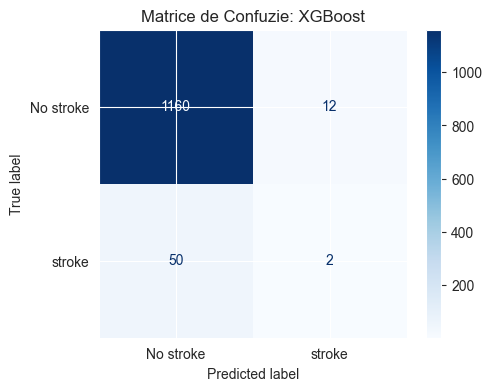

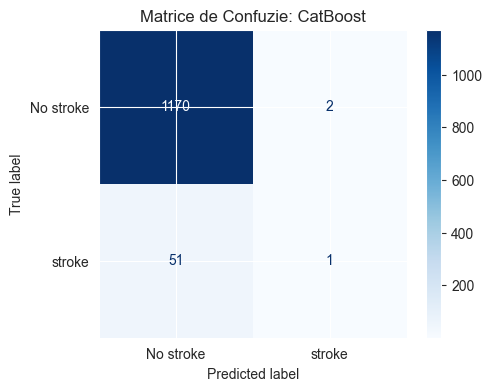

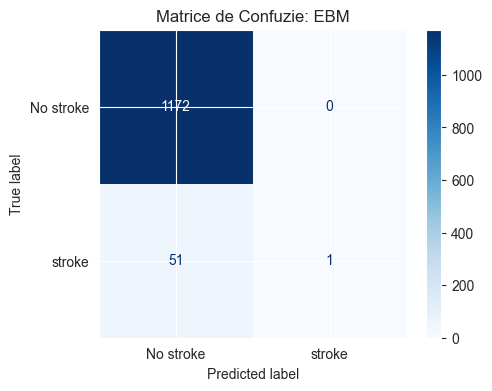

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
1  Logistic Regression  0.958333   1.000000  0.019231  0.037736  0.811991
8                  EBM  0.958333   1.000000  0.019231  0.037736  0.810629
0          Naive Bayes  0.223039   0.050949  0.980769  0.096866  0.807085
7             CatBoost  0.956699   0.333333  0.019231  0.036364  0.798389
6              XGBoost  0.949346   0.142857  0.038462  0.060606  0.792153
3        Random Forest  0.958333   1.000000  0.019231  0.037736  0.752305
4                  SVM  0.957516   0.000000  0.000000  0.000000  0.611135
5                  KNN  0.955882   0.000000  0.000000  0.000000  0.585570
2        Decision Tree  0.922386   0.122807  0.134615  0.128440  0.545977


In [25]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No stroke', 'stroke'])
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    ax.set_title(f"Matrice de Confuzie: {name}")
    plt.show()

    fig.savefig(f"clasificare_files/cm_{name.lower().replace(' ', '_')}.png")


df_results = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print(df_results)

### 3. Antrenarea si compararea modelelor de baza
* **Metodologie**: Am evaluat o gama larga de algoritmi, de la modele simple precum **Naive Bayes** si **Logistic Regression**, pana la modele de tip ensemble ca **Random Forest**, **XGBoost** si **CatBoost**.
* **Evaluare**: Din cauza dezechilibrului claselor, am pus accent pe **ROC-AUC** si **F1-Score**. Modelele bazate pe arbori au demonstrat o capacitate superioara de a capta relatiile complexe dintre variabilele medicale fara a necesita o scalare prealabila riguroasa.


### Metricile de testare:
Pentru a evalua corect performanta modelelor, am utilizat urmatoarele metrici standard:
* **Accuracy**: Reprezinta procentul de predictii corecte din totalul cazurilor.
* **Precision**: Indica ce procent dintre persoanele identificate de model ca fiind la risc de AVC au avut intr-adevar aceasta afectiune.
* **Recall**: Este cea mai importanta metrica in medicina. Arata capacitatea modelului de a detecta toti pacientii care au suferit un AVC.
* **F1-Score**: Este media armonica intre Precision si Recall, oferind un echilibru intre cele doua.
* **ROC-AUC**: Masoara capacitatea modelului de a distinge intre cele doua clase (AVC vs. fara AVC)
* **Matricea de confuzie**: Reprezinta un instrument de vizualizare a performantei modelului, comparand valorile reale cu cele prezise. Contine 4 cadrane:
    * **True Positives (TP)**: Pacienti care au suferit un AVC si au fost identificati corect de model.
    * **True Negatives (TN)**: Pacienti sanatosi identificati corect ca neavand risc de AVC.
    * **False Positives (FP)**: Alarme false, unde modelul prezice risc de AVC pentru un pacient sanatos.
    * **False Negatives (FN)**: Cazuri ratate, unde modelul clasifica un pacient bolnav ca fiind sanatos. Aceasta reprezinta cea mai grava eroare in context medical, deoarece poate duce la omiterea tratamentului necesar.

In [26]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 200, 500]
}

grid_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_lr.fit(X_train, y_train)

print(f"Cele mai bune hiperparametre LR: {grid_lr.best_params_}")
print(f"Cel mai bun scor ROC-AUC: {grid_lr.best_score_:.4f}")

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)
y_proba_lr = best_lr.predict_proba(X_test)[:, 1]

print(f"Recall dupa tuning: {recall_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC dupa tuning: {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"Accuracy dupa tuning: {accuracy_score(y_test, y_pred_lr):.4f}")

Cele mai bune hiperparametre LR: {'C': 0.01, 'max_iter': 100, 'solver': 'lbfgs'}
Cel mai bun scor ROC-AUC: 0.8571
Recall dupa tuning: 0.7692
ROC-AUC dupa tuning: 0.8171
Accuracy dupa tuning: 0.7459


In [27]:
weights = compute_sample_weight(class_weight='balanced', y=y_train)


best_ebm = ExplainableBoostingClassifier(
    interactions=15,
    learning_rate=0.02,
    max_bins=512,
    random_state=42
)

best_ebm.fit(X_train, y_train, sample_weight=weights)


y_pred_ebm = best_ebm.predict(X_test)
y_proba_ebm = best_ebm.predict_proba(X_test)[:, 1]

print(f"Recall EBM dupa tuning: {recall_score(y_test, y_pred_ebm):.4f}")
print(f"ROC-AUC EBM dupa tuning: {roc_auc_score(y_test, y_proba_ebm):.4f}")
print(f"Accuracy EBM dupa tuning: {accuracy_score(y_test, y_pred_ebm):.4f}")

Recall EBM dupa tuning: 0.7885
ROC-AUC EBM dupa tuning: 0.8080
Accuracy EBM dupa tuning: 0.7328


In [28]:
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=20),
    'priors': [[0.5, 0.5], [0.6, 0.4], [0.7, 0.3], [0.8, 0.2]]
}
grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_nb.fit(X_train, y_train)
print(f"Cele mai bune hiperparametre NB: {grid_nb.best_params_}")
print(f"Cel mai bun scor ROC-AUC CV: {grid_nb.best_score_:.4f}")


best_nb = grid_nb.best_estimator_
y_pred_nb = best_nb.predict(X_test)
y_proba_nb = best_nb.predict_proba(X_test)[:, 1]


print(f"Recall: {recall_score(y_test, y_pred_nb):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_nb):.4f}")

Cele mai bune hiperparametre NB: {'priors': [0.5, 0.5], 'var_smoothing': np.float64(0.3359818286283782)}
Cel mai bun scor ROC-AUC CV: 0.8420
Recall: 0.7500
Accuracy: 0.7059
ROC-AUC: 0.8053


In [29]:
param_grid_cat = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.03, 0.1],
    'iterations': [200, 500],
    'l2_leaf_reg': [1, 3, 5]
}

grid_cat = GridSearchCV(
    CatBoostClassifier(auto_class_weights='Balanced', silent=True, random_state=42),
    param_grid_cat,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_cat.fit(X_train, y_train)

print(f"Cele mai bune hiperparametre CatBoost: {grid_cat.best_params_}")
print(f"Cel mai bun scor ROC-AUC CV: {grid_cat.best_score_:.4f}")

best_cat = grid_cat.best_estimator_
y_pred_cat = best_cat.predict(X_test)
y_proba_cat = best_cat.predict_proba(X_test)[:, 1]

print(f"Recall CatBoost dupa tuning: {recall_score(y_test, y_pred_cat):.4f}")
print(f"ROC-AUC CatBoost dupa tuning: {roc_auc_score(y_test, y_proba_cat):.4f}")
print(f"Accuracy CatBoost dupa tuning: {accuracy_score(y_test, y_pred_cat):.4f}")


Cele mai bune hiperparametre CatBoost: {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 5, 'learning_rate': 0.01}
Cel mai bun scor ROC-AUC CV: 0.8538
Recall CatBoost dupa tuning: 0.8077
ROC-AUC CatBoost dupa tuning: 0.8177
Accuracy CatBoost dupa tuning: 0.7075


In [30]:
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(scale_pos_weight=22.38, random_state=42, eval_metric='logloss'),
    param_grid_xgb,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print(f"Cele mai bune hiperparametre XGBoost: {grid_xgb.best_params_}")
print(f"Cel mai bun scor ROC-AUC CV: {grid_xgb.best_score_:.4f}")

best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print(f"Recall XGBoost dupa tuning: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC XGBoost dupa tuning: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"Accuracy XGBoost dupa tuning: {accuracy_score(y_test, y_pred_xgb):.4f}")

Cele mai bune hiperparametre XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Cel mai bun scor ROC-AUC CV: 0.8438
Recall XGBoost dupa tuning: 0.7500
ROC-AUC XGBoost dupa tuning: 0.8180
Accuracy XGBoost dupa tuning: 0.7230


### 4. Ajustarea hiperparametrilor
* **Optimizare**: Am utilizat **GridSearchCV** pentru a cauta combinatia optima de parametri pentru cele mai bune 5 modele.
* **Focus**: Ne-am concentrat pe reglarea **adancimii arborilor** si a **learning rate-ului**. In cazul modelelor de tip boosting, am monitorizat numarul de iteratii pentru a atinge un echilibru intre performanta pe clasa pozitiva si riscul de **overfitting**.

In [31]:
def plot_learning_curves(estimator, X, y, name):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=3, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='roc_auc'
    )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    fig = plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Scor antrenare")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Scor validare")
    plt.title(f"Curba de invatare - {name}")
    plt.xlabel("Dimensiunea setului de antrenare")
    plt.ylabel("ROC-AUC")
    plt.legend(loc="best")
    plt.grid(True)

    filename = f"clasificare_files/learning_curve_{name.lower().replace(' ', '_')}.png"
    plt.savefig(filename)
    plt.close(fig)



FileNotFoundError: [Errno 2] No such file or directory: 'clasificare_files/learning_curve_log._regression.png'

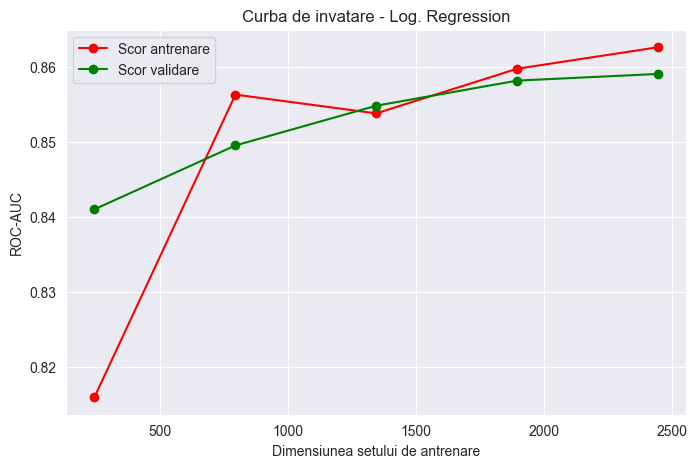

In [32]:
top_5_models = [
    ("CatBoost", best_cat),
    ("EBM", best_ebm),
    ("Log. Regression", grid_lr),
    ("XGBoost", best_xgb),
    ("Naive Bayes", grid_nb)
]

for name, model in top_5_models:
    plot_learning_curves(model, X_train, y_train, name)

### 5. Curbele de invatare
* **Analiza**: Graficele arata modul in care modelele noastre profita de cresterea numarului de date.
* **Diagnostic**: Convergenta curbelor de antrenare si validare la majoritatea modelelor selectate indica faptul ca sistemul este stabil si are o buna **capacitate de generalizare**. Diferenta mica dintre cele doua curbe sugereaza faptul ca modelul nu a memorat datele, ci a invatat tipare medicale reale.

In [39]:

explainer_cat = shap.TreeExplainer(best_cat)
shap_values_cat = explainer_cat.shap_values(X_test)

shap.plots.bar(explainer_cat(X_test), show=False)
plt.title("Importanta globala a caracteristicilor: CatBoost")
plt.savefig("clasificare_files/shap_bar_catboost.png", bbox_inches='tight')
plt.close()

shap.summary_plot(shap_values_cat, X_test, show=False)
plt.title("Impactul variabilelor asupra predictiei: CatBoost")
plt.savefig("clasificare_files/shap_summary_catboost.png", bbox_inches='tight')
plt.close()

shap.plots.waterfall(explainer_cat(X_test)[0], show=False)
plt.title("Explicatie locala: contributia factorilor pentru primul pacient: CatBoost")
plt.savefig("clasificare_files/shap_waterfall_catboost.png", bbox_inches='tight')
plt.close()

shap.force_plot(explainer_cat.expected_value, shap_values_cat[0], X_test.iloc[0], matplotlib=True, show=False)
plt.title("Force Plot: Factorii de decizie individuali pentru primul pacient CatBoost")
plt.savefig("clasificare_files/shap_force_catboost.png", bbox_inches='tight')
plt.close()

for col in ["age", "avg_glucose_level"]:
    plt.figure()
    shap.plots.scatter(explainer_cat(X_test)[:, col], show=False)
    plt.savefig(f"clasificare_files/shap_scatter_{col}_catboost.png")
    plt.close()

C:\Users\denis\AppData\Local\Temp\ipykernel_35672\4085630094.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_cat, X_test, show=False)


In [40]:
explainer_ebm = shap.Explainer(best_ebm.predict, X_train)
shap_values_ebm = explainer_ebm(X_test)


shap.plots.bar(shap_values_ebm, show=False)
plt.title("Importanta globala a caracteristicilor: EBM")
plt.savefig("clasificare_files/shap_bar_ebm.png", bbox_inches='tight')
plt.close()

shap.plots.beeswarm(shap_values_ebm, show=False)
plt.title("Impactul variabilelor asupra predictiei: EBM")
plt.savefig("clasificare_files/shap_summary_ebm.png", bbox_inches='tight')
plt.close()

shap.plots.waterfall(shap_values_ebm[0], show=False)
plt.title("Explicatie locala: contributia factorilor pentru primul pacient: EBM")
plt.savefig("clasificare_files/shap_waterfall_ebm.png", bbox_inches='tight')
plt.close()

shap.plots.force(shap_values_ebm[0], matplotlib=True, show=False)
plt.title("Force Plot: Factorii de decizie individuali pentru primul pacient EBM")
plt.savefig("clasificare_files/shap_force_ebm.png", bbox_inches='tight')
plt.close()

for col in ["age", "avg_glucose_level"]:
    plt.figure()
    shap.plots.scatter(shap_values_ebm[:, col], show=False)
    plt.savefig(f"clasificare_files/shap_scatter_{col}_ebm.png")
    plt.close()


PermutationExplainer explainer: 1225it [00:41, 22.51it/s]                          


In [42]:
explainer_lr = shap.LinearExplainer(grid_lr.best_estimator_, X_train)
shap_values_lr = explainer_lr(X_test)

shap.plots.bar(shap_values_lr, show=False)
plt.title("Importanta globala a caracteristicilor - Logistic Regression")
plt.savefig("clasificare_files/shap_bar_logreg.png", bbox_inches='tight')
plt.close()

shap.plots.beeswarm(shap_values_lr, show=False)
plt.title("Impactul variabilelor asupra predictiei: Logistic Regression")
plt.savefig("clasificare_files/shap_summary_logreg.png", bbox_inches='tight')
plt.close()

shap.plots.waterfall(shap_values_lr[0], show=False)
plt.title("Explicatie locala: contributia factorilor pentru primul pacient: Logistic Regression")
plt.savefig("clasificare_files/shap_waterfall_logreg.png", bbox_inches='tight')
plt.close()

shap.plots.force(shap_values_lr[0], matplotlib=True, show=False)
plt.title("Force Plot: Factorii de decizie individuali pentru primul pacient Logistic Regression")
plt.savefig("clasificare_files/shap_force_logreg.png", bbox_inches='tight')
plt.close()

for col in ["age", "avg_glucose_level"]:
    shap.plots.scatter(shap_values_lr[:, col], show=False)
    plt.title(f"Dependenta {col} - LogReg")
    plt.savefig(f"clasificare_files/shap_scatter_{col}_logreg.png", bbox_inches='tight')
    plt.close()


In [48]:
path_modele = 'clasificare_files/modele/'
if not os.path.exists(path_modele):
    os.makedirs(path_modele)


joblib.dump(best_cat, f'{path_modele}model_cat.pkl')
joblib.dump(best_ebm, f'{path_modele}model_ebm.pkl')
joblib.dump(grid_lr.best_estimator_, f'{path_modele}model_lr.pkl')
joblib.dump(best_xgb, f'{path_modele}model_xgb.pkl')
joblib.dump(grid_nb.best_estimator_, f'{path_modele}model_nb.pkl')


['clasificare_files/modele/model_nb.pkl']

### 6. Explicabilitate si analiza SHAP
* **Importanta Globala**: Analiza **SHAP** a confirmat intuitia clinica: **age** (varsta) este cel mai puternic predictor pentru AVC, urmat de nivelul de glucoza.
